# 1. Business Problem
# Customer Churn Prediction

Customer churn refers to customers who stop using a company's service.

The objective of this project is to predict whether a customer is likely to churn based on customer demographics, subscription details, billing information, and service usage.

By identifying customers who are likely to churn, the telecom company can proactively *o*

# ***2. Import Libraries***

Machine Learning projects require different Python libraries for different tasks.

• Pandas – Data loading and manipulation
• NumPy – Numerical computations
• Matplotlib & Seaborn – Data visualization
• Scikit-learn – Machine learning models and preprocessing
• XGBoost – Gradient boosting algorithm




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 3. Load Dataset
The first step is to load the dataset into a Pandas DataFrame.

This allows us to inspect the data, understand its structure, and perform preprocessing before building machine learning models.

In [2]:
df=pd.read_excel("/content/Telco_customer_churn.xlsx",)

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# 4. Data Understanding
Before building any machine learning model, it is important to understand the dataset.

This includes:

• Number of rows and columns
• Data types
• Target variable
• Missing values
• Duplicate records
• Meaning of each feature

Understanding the dataset helps identify unnecessary columns, data quality issues, and potential preprocessing steps.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.shape

(7043, 33)

In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

# 5. Missing Values
Missing values can affect model performance.

Before handling them, we should understand why they exist.

Missing values caused by data collection errors should be treated differently from missing values that have a business meaning.

The appropriate handling method depends on the reason behind the missing data.

In [7]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [10]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [11]:
df['Churn Value'].value_counts(normalize=True)*100

,proportion
Churn Value,
0,73.463013
1,26.536987


In [12]:
df['State'].nunique()

1

In [13]:
df['City'].nunique()

1129

In [14]:
df['Count'].nunique()

1

In [15]:
df=df.drop('CustomerID',axis=1)

In [16]:
df=df.drop('Count',axis=1)

In [17]:
df['Zip Code'].nunique()

1652

In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7043 non-null   object 
 1   State              7043 non-null   object 
 2   City               7043 non-null   object 
 3   Zip Code           7043 non-null   int64  
 4   Lat Long           7043 non-null   object 
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   object 
 8   Senior Citizen     7043 non-null   object 
 9   Partner            7043 non-null   object 
 10  Dependents         7043 non-null   object 
 11  Tenure Months      7043 non-null   int64  
 12  Phone Service      7043 non-null   object 
 13  Multiple Lines     7043 non-null   object 
 14  Internet Service   7043 non-null   object 
 15  Online Security    7043 non-null   object 
 16  Online Backup      7043 

In [19]:
df=df.drop('Churn Reason',axis=1)

In [20]:
df=df.drop('Lat Long',axis=1)

In [21]:
df=df.drop('CLTV',axis=1)

In [22]:
df=df.drop('Churn Label',axis=1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7043 non-null   object 
 1   State              7043 non-null   object 
 2   City               7043 non-null   object 
 3   Zip Code           7043 non-null   int64  
 4   Latitude           7043 non-null   float64
 5   Longitude          7043 non-null   float64
 6   Gender             7043 non-null   object 
 7   Senior Citizen     7043 non-null   object 
 8   Partner            7043 non-null   object 
 9   Dependents         7043 non-null   object 
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   object 
 12  Multiple Lines     7043 non-null   object 
 13  Internet Service   7043 non-null   object 
 14  Online Security    7043 non-null   object 
 15  Online Backup      7043 non-null   object 
 16  Device Protection  7043 

In [24]:
df["Longitude"].nunique()

1651

In [25]:
df["Latitude"].nunique()

1652

In [26]:
df["Country"].nunique()

1

In [27]:
df=df.drop('Country',axis=1)

# 6. Exploratory Data Analysis (EDA)
Exploratory Data Analysis helps us understand the relationships between features and the target variable.

EDA is performed to:

• Understand customer behavior
• Detect patterns
• Identify important features
• Discover trends that may influence churn

The conclusions drawn from EDA are validated later using machine learning models.

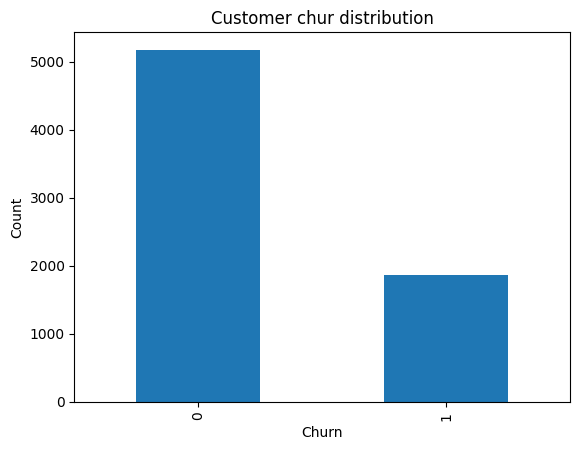

In [28]:
df['Churn Value'].value_counts().plot(kind='bar')
plt.title('Customer chur distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [29]:
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418
std,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000


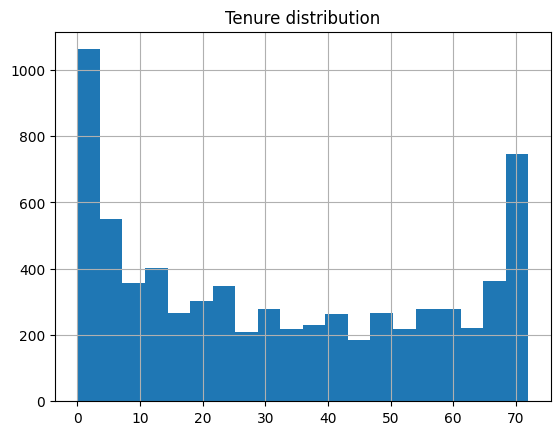

In [30]:
df['Tenure Months'].hist(bins=20)
plt.title('Tenure distribution')
plt.show()

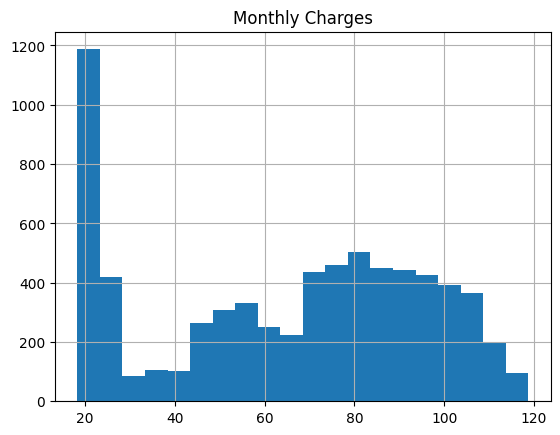

In [31]:
df["Monthly Charges"].hist(bins=20)
plt.title("Monthly Charges")
plt.show()

In [32]:
pd.crosstab(df["Contract"], df["Churn Value"])

Churn Value,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


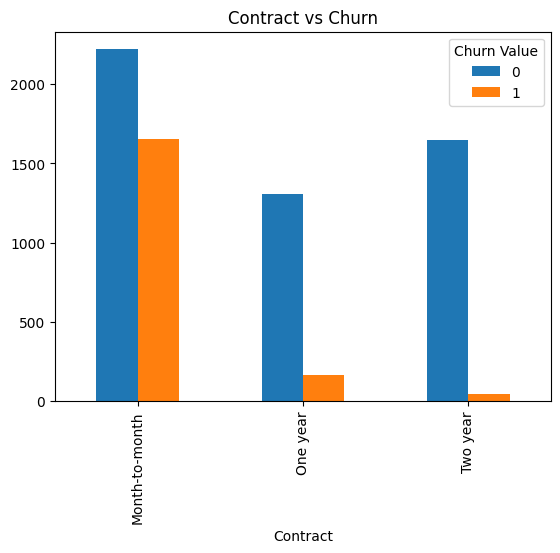

In [33]:
pd.crosstab(
    df["Contract"],
    df["Churn Value"]
).plot(kind="bar")

plt.title("Contract vs Churn")
plt.show()

In [34]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"]
)

Churn Value,0,1
Senior Citizen,,
No,4508,1393
Yes,666,476


In [35]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Value"]
)

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [36]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Value"]
)

Churn Value,0,1
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [37]:
df.groupby("Contract")["Monthly Charges"].mean()

,Monthly Charges
Contract,
Month-to-month,66.398490
One year,65.048608
Two year,60.770413


In [38]:
df.groupby("Churn Value")["Tenure Months"].mean()

,Tenure Months
Churn Value,
0,37.569965
1,17.979133


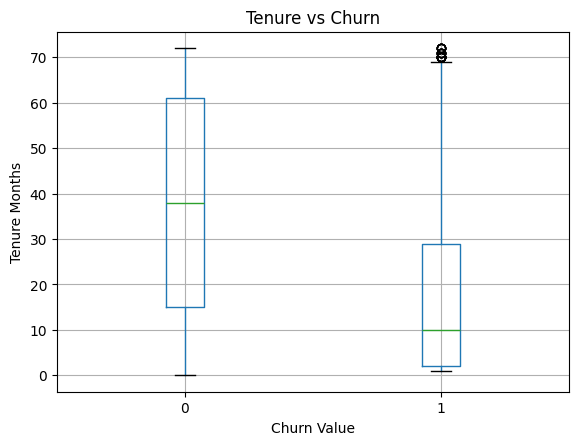

In [39]:
df.boxplot(column="Tenure Months", by="Churn Value")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn Value")
plt.ylabel("Tenure Months")
plt.show()

# 7. Feature Engineering
Not every column contributes to predicting customer churn.

Feature engineering involves:

• Removing unnecessary features
• Removing data leakage
• Creating useful features if required
• Selecting features that improve model performance

Good feature engineering often has a greater impact than choosing a more complex model.

In [40]:
pd.crosstab(
    [df["Contract"], df["Internet Service"]],
    df["Churn Value"],
    normalize="index"
) * 100

Churn Value                              0          1
Contract       Internet Service                      
Month-to-month DSL               67.784137  32.215863
               Fiber optic       45.394737  54.605263
               No                81.106870  18.893130
One year       DSL               90.701754   9.298246
               Fiber optic       80.705009  19.294991
               No                97.527473   2.472527
Two year       DSL               98.089172   1.910828
               Fiber optic       92.773893   7.226107
               No                99.216301   0.783699

In [41]:
df.groupby("Churn Value")["Monthly Charges"].mean()

,Monthly Charges
Churn Value,
0,61.265124
1,74.441332


In [42]:
df['Total Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5], dtype=object)

In [43]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [44]:
df['Total Charges'].dtype

dtype('float64')

In [45]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Reason",
    "Churn Score"
]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              7043 non-null   object 
 1   City               7043 non-null   object 
 2   Zip Code           7043 non-null   int64  
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   object 
 6   Senior Citizen     7043 non-null   object 
 7   Partner            7043 non-null   object 
 8   Dependents         7043 non-null   object 
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   object 
 11  Multiple Lines     7043 non-null   object 
 12  Internet Service   7043 non-null   object 
 13  Online Security    7043 non-null   object 
 14  Online Backup      7043 non-null   object 
 15  Device Protection  7043 non-null   object 
 16  Tech Support       7043 

In [46]:
df['State'].unique()

array(['California'], dtype=object)

In [47]:
df=df.drop('Churn Score',axis=1)

In [48]:
df=df.drop('State',axis=1)

In [49]:
x=df.drop('Churn Value',axis=1)
y=df['Churn Value']

# 8. Train-Test Split
The dataset is divided into training and testing sets.

Training data is used to learn patterns.

Testing data is used to evaluate how well the model performs on completely unseen customers.

Keeping test data separate helps estimate real-world performance.

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [51]:
x_train.select_dtypes(include='object').columns

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object')

# 9. One-Hot Encoding
Machine learning models cannot directly understand categorical values such as "Male", "Female", or "Month-to-month".

One-Hot Encoding converts each category into separate binary columns.

This prevents the model from assuming an incorrect numerical order between categories.

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown='ignore')
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [53]:
numerical_features=x_train.select_dtypes(include=['int64','float64']).columns

In [54]:
categorical_features=x_train.select_dtypes(include='object').columns


# 10. Data Preprocessing
Machine learning models require clean numerical data.

The preprocessing stage includes:

• Handling missing values
• Encoding categorical variables
• Scaling numerical features
• Preparing the data for machine learning algorithms

Proper preprocessing improves model performance and prevents data leakage.

In [55]:
numeric_transformer=StandardScaler()

In [56]:
categorical_transformer=OneHotEncoder(handle_unknown='ignore')

In [57]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [58]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression())
    ]
)

In [59]:
x_train.isnull().sum().sort_values(ascending=False)

,0
Total Charges,8
Zip Code,0
City,0
Longitude,0
Gender,0
Senior Citizen,0
Latitude,0
Partner,0
Dependents,0
Phone Service,0


In [60]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [61]:
df[df["Total Charges"].isnull()][
    ["Tenure Months", "Monthly Charges", "Total Charges"]
]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [62]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [63]:
x=df.drop('Churn Value',axis=1)
y=df['Churn Value']

In [64]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# 11. Pipeline
A Machine Learning Pipeline automates preprocessing and model training.

Advantages:

• Prevents data leakage
• Makes code cleaner
• Ensures identical preprocessing during training and prediction
• Simplifies deployment

In [65]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [66]:
y_pred = pipeline.predict(x_test)
print(y_pred[:10])

[0 1 0 0 0 1 1 0 0 0]


In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7913413768630234


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[908 127]
 [167 207]]


# 13. Logistic Regression
Logistic Regression is used as a baseline classification model.

Advantages:

• Fast training
• Easy to interpret
• Performs well on structured tabular data
• Provides probability estimates

It serves as a good starting point before trying more complex models.

In [70]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [71]:
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

[[776 259]
 [ 89 285]]


# 14. Decision Tree
Decision Trees split the data into smaller groups based on feature values.

Advantages:

• Easy to understand
• Handles nonlinear relationships
• No feature scaling required

Disadvantage:

Decision Trees easily overfit if allowed to grow without restrictions.

In [73]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [74]:
tree_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [75]:
y_pred_tree = tree_pipeline.predict(x_test)

In [76]:
print("Training Accuracy:",
      tree_pipeline.score(x_train, y_train))

print("Testing Accuracy:",
      tree_pipeline.score(x_test, y_test))


Training Accuracy: 1.0
Testing Accuracy: 0.7537260468417317


In [77]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.7537260468417317
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1035
           1       0.54      0.50      0.52       374

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.68      1409
weighted avg       0.75      0.75      0.75      1409

[[875 160]
 [187 187]]


# 15. Random Forest
Random Forest is an ensemble learning algorithm based on Bagging.

It builds multiple Decision Trees using random subsets of data and features.

Final predictions are made using majority voting.

Random Forest reduces variance and generally performs better than a single Decision Tree.

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

In [79]:
rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [80]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_pred_rf = rf_pipeline.predict(x_test)

print("Training Accuracy:", rf_pipeline.score(x_train, y_train))
print("Testing Accuracy:", rf_pipeline.score(x_test, y_test))

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Training Accuracy: 1.0
Testing Accuracy: 0.8026969481902059
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[943  92]
 [186 188]]


In [81]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multi...
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='recall')

In [82]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Recall:")
print(grid_rf.best_score_)

Best Parameters:
{'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Cross Validation Recall:
0.4668896321070234


In [83]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(x_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[951  84]
 [192 182]]


In [84]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
3,num__Tenure Months,0.084222
1168,cat__Contract_Month-to-month,0.074957
5,num__Total Charges,0.061542
1159,cat__Tech Support_No,0.039227
4,num__Monthly Charges,0.038530
1150,cat__Online Security_No,0.037353
1141,cat__Dependents_Yes,0.035582
1170,cat__Contract_Two year,0.031691
1148,cat__Internet Service_Fiber optic,0.030335
1140,cat__Dependents_No,0.028106


# 16. XGBoost
XGBoost is an ensemble learning algorithm based on Gradient Boosting.

Unlike Random Forest, trees are built sequentially.

Each new tree learns from the mistakes made by previous trees.

XGBoost often achieves higher predictive performance and is widely used in machine learning competitions and industry applications.

In [85]:
from xgboost import XGBClassifier

In [86]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [88]:
xgb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [89]:
y_pred = xgb_pipeline.predict(x_test)

In [90]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Training Accuracy:",
      xgb_pipeline.score(x_train, y_train))

print("Testing Accuracy:",
      xgb_pipeline.score(x_test, y_test))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.9501242456514022
Testing Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

[[908 127]
 [171 203]]


# 17. Hyperparameter Tuning
Hyperparameters control how a machine learning model learns.

GridSearchCV systematically evaluates different hyperparameter combinations using cross-validation.

The best combination is selected based on the chosen evaluation metric.

In [92]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multi...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1, 0.2],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='recall')

In [93]:
print("Best Parameters:")
print(grid_xgb.best_params_)

print("Best CV Recall:")
print(grid_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Recall:
0.577257525083612


# 18. Model Evaluation
Classification models are evaluated using multiple metrics.

Accuracy measures overall correctness.

Precision measures how many predicted churn customers actually churned.

Recall measures how many actual churn customers were correctly identified.

F1-score balances Precision and Recall.

Since the business objective is customer retention, Recall is considered the most important metric in this project.

In [95]:
best_xgb = grid_xgb.best_estimator_

y_pred = best_xgb.predict(x_test)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("Training Accuracy:",
      best_xgb.score(x_train, y_train))

print("Testing Accuracy:",
      best_xgb.score(x_test, y_test))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.8354632587859425
Testing Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

[[925 110]
 [173 201]]


# 19. Feature Importance
Feature Importance identifies which variables contribute most to model predictions.

Understanding feature importance helps explain the model and provides valuable business insights for decision-making.

It also helps identify the factors that most strongly influence customer churn.

In [96]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1168,cat__Contract_Month-to-month,0.344851
1148,cat__Internet Service_Fiber optic,0.077138
1159,cat__Tech Support_No,0.071984
1150,cat__Online Security_No,0.070964
1170,cat__Contract_Two year,0.038930
1140,cat__Dependents_No,0.036392
1175,cat__Payment Method_Electronic check,0.032876
3,num__Tenure Months,0.023737
1171,cat__Paperless Billing_No,0.019791
1169,cat__Contract_One year,0.017885


In [97]:
y_prob = best_xgb.predict_proba(x_test)[:, 1]

# 20. ROC-AUC
ROC-AUC measures the model's ability to distinguish between churn and non-churn customers across different classification thresholds.

A higher ROC-AUC score indicates better discrimination between the two classes.

Unlike accuracy, ROC-AUC is independent of a single decision threshold.

In [98]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.8544072437934331


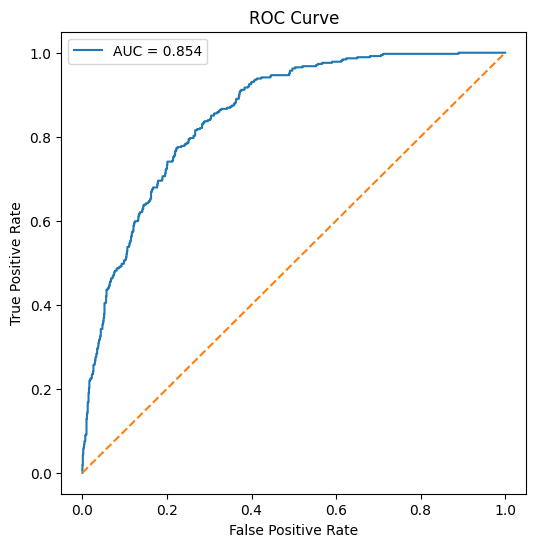

In [99]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [100]:
import joblib

joblib.dump(best_xgb, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']

In [101]:
model = joblib.load("xgboost_churn_model.pkl")

# 21. Business Recommendations
Based on the model results, customers with short tenure, month-to-month contracts, no technical support, fiber optic internet service, and electronic check payment methods are at higher risk of churn.

The company should focus on these customer segments by providing personalized offers, improved technical support, loyalty programs, and incentives to encourage long-term subscriptions.